Training with Adam...
Epoch     0  Loss = 9.319468e+03
Epoch    50  Loss = 9.419968e+03
Epoch   100  Loss = 8.642422e+03
Epoch   150  Loss = 8.367696e+03
Epoch   200  Loss = 1.029004e+04
Epoch   250  Loss = 9.960181e+03
Epoch   300  Loss = 8.024789e+03
Epoch   350  Loss = 8.552040e+03
Epoch   400  Loss = 9.684018e+03
Epoch   450  Loss = 9.578855e+03


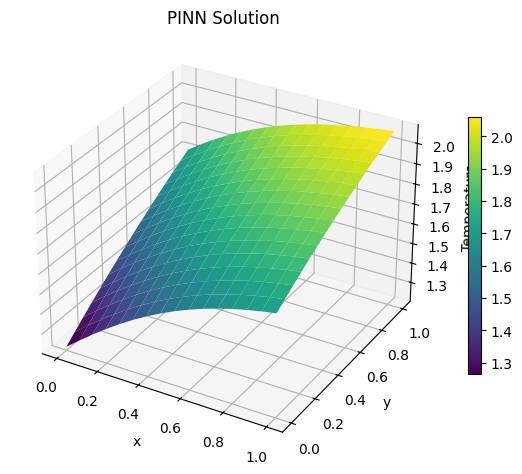

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# Parameters
# ==========================================================

torch.manual_seed(1234)
np.random.seed(1234)

# ==========================================================
# PINN Network
# ==========================================================

class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 4),
            nn.Tanh(),

            nn.Linear(4, 1)
        )

    def forward(self, x, y):
        return self.net(torch.cat([x, y], dim=1))


model = PINN()

# ==========================================================
# Optimizer
# ==========================================================

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ==========================================================
# PINN Loss
# ==========================================================

def pinn_loss():

    # ------------------------------------------------------
    # Interior points
    # ------------------------------------------------------

    Nf = 16

    x = torch.rand(Nf, 1, requires_grad=True )

    y = torch.rand(Nf, 1, requires_grad=True )

    u = model(x, y)

    # ------------------------------------------------------
    # u_x
    # ------------------------------------------------------

    u_x = torch.autograd.grad(u,x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # ------------------------------------------------------
    # u_xx
    # ------------------------------------------------------

    u_xx = torch.autograd.grad(u_x,x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    # ------------------------------------------------------
    # u_y
    # ------------------------------------------------------

    u_y = torch.autograd.grad(u,y,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # ------------------------------------------------------
    # u_yy
    # ------------------------------------------------------

    u_yy = torch.autograd.grad(u_y,y,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True
    )[0]

    # ------------------------------------------------------
    # 2D Laplace Equation # u_xx + u_yy = 0
    # ------------------------------------------------------

    loss_pde = (u_xx + u_yy).pow(2).mean()

    # ======================================================
    # Left Boundary u(0,y) = 10
    # ======================================================

    Nb = 6

    yb = torch.rand(Nb, 1)

    xl = torch.zeros_like(yb)

    ul = model(xl, yb)

    loss_left = ((ul - 10.0) ** 2).mean()

    # ======================================================
    # Right Boundary  u(1,y) = 20
    # ======================================================

    xr = torch.ones_like(yb)

    ur = model(xr, yb)

    loss_right = ((ur - 20.0) ** 2).mean()

    # ======================================================
    # Bottom Boundary u(x,0) = 10 + 10x
    # ======================================================

    xb = torch.rand(Nb, 1)

    y_bottom = torch.zeros_like(xb)

    ub = model(xb, y_bottom)

    target_bottom = 10.0 + 10.0 * xb

    loss_bottom = ((ub - target_bottom) ** 2).mean()

    # ======================================================
    # Top Boundary u(x,1) = 10 + 10x
    # ======================================================

    y_top = torch.ones_like(xb)

    utop = model(xb, y_top)

    target_top = 10.0 + 10.0 * xb

    loss_top = ((utop - target_top) ** 2).mean()

    # ======================================================
    # Total PINN Loss
    # ======================================================

    loss = (loss_pde + 10 * loss_left + 10 * loss_right + 10 * loss_bottom + 10 * loss_top  )

    return loss


# ==========================================================
# Training
# ==========================================================

epochs = 500

print("Training with Adam...")

for epoch in range(epochs):

    loss = pinn_loss()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 50 == 0:

        print(f"Epoch {epoch:5d}  " f"Loss = {loss.item():.6e}")


# ==========================================================
# Prediction
# ==========================================================

n_test = 16

x_test = torch.linspace(0, 1, n_test)

y_test = torch.linspace(0, 1, n_test)

X, Y = torch.meshgrid(x_test, y_test, indexing="ij")

x_flat = X.reshape(-1, 1)
y_flat = Y.reshape(-1, 1)

# ----------------------------------------------------------
# PINN Prediction
# ----------------------------------------------------------

with torch.no_grad():

    u_pinn = model( x_flat, y_flat )

u_pinn = u_pinn.reshape( n_test, n_test).numpy()


# ==========================================================
# Plot: PINN Solution
# ==========================================================

fig = plt.figure()

ax1 = fig.add_subplot(1, 1, 1, projection="3d")

surf1 = ax1.plot_surface(X.numpy(), Y.numpy(), u_pinn, cmap="viridis")

ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("Temperature")

ax1.set_title("PINN Solution")

fig.colorbar(surf1, ax=ax1,shrink=0.6)

plt.tight_layout()

plt.show()

Training with Adam...
Epoch     0  Loss = 9.612035e+03
Epoch  1000  Loss = 6.129605e-01
Epoch  2000  Loss = 4.312535e-01
Epoch  3000  Loss = 2.335222e-01
Epoch  4000  Loss = 1.184111e-01


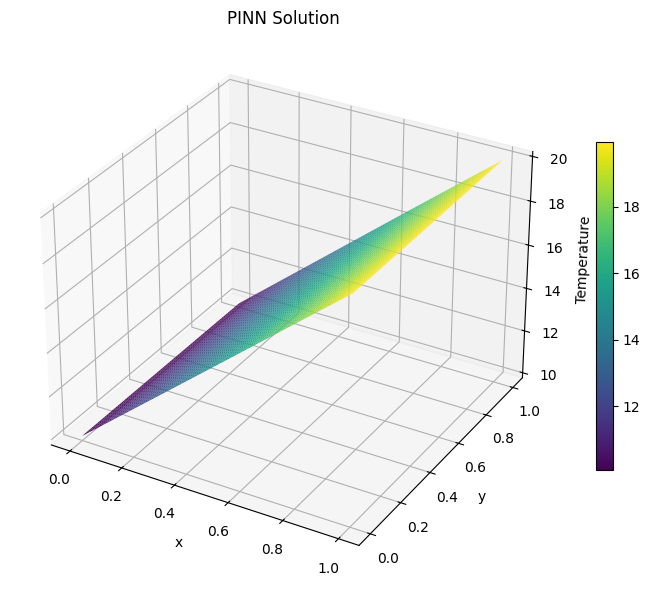

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# Parameters
# ==========================================================

torch.manual_seed(1234)
np.random.seed(1234)

# ==========================================================
# PINN Network
# ==========================================================

class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 1)
        )

    def forward(self, x, y):
        return self.net(torch.cat([x, y], dim=1))


model = PINN()

# ==========================================================
# Optimizer
# ==========================================================

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ==========================================================
# PINN Loss
# ==========================================================

def pinn_loss():

    # ------------------------------------------------------
    # Interior points
    # ------------------------------------------------------

    Nf = 16

    x = torch.rand(Nf, 1, requires_grad=True )

    y = torch.rand(Nf, 1, requires_grad=True )

    u = model(x, y)

    # ------------------------------------------------------
    # u_x
    # ------------------------------------------------------

    u_x = torch.autograd.grad(u,x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # ------------------------------------------------------
    # u_xx
    # ------------------------------------------------------

    u_xx = torch.autograd.grad(u_x,x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    # ------------------------------------------------------
    # u_y
    # ------------------------------------------------------

    u_y = torch.autograd.grad(u,y,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # ------------------------------------------------------
    # u_yy
    # ------------------------------------------------------

    u_yy = torch.autograd.grad(u_y,y,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True
    )[0]

    # ------------------------------------------------------
    # 2D Laplace Equation
    #
    # u_xx + u_yy = 0
    # ------------------------------------------------------

    loss_pde = (u_xx + u_yy).pow(2).mean()

    # ======================================================
    # Left Boundary u(0,y) = 10
    # ======================================================

    Nb = 500

    yb = torch.rand(Nb, 1)

    xl = torch.zeros_like(yb)

    ul = model(xl, yb)

    loss_left = ((ul - 10.0) ** 2).mean()

    # ======================================================
    # Right Boundary  u(1,y) = 20
    # ======================================================

    xr = torch.ones_like(yb)

    ur = model(xr, yb)

    loss_right = ((ur - 20.0) ** 2).mean()

    # ======================================================
    # Bottom Boundary u(x,0) = 10 + 10x
    # ======================================================

    xb = torch.rand(Nb, 1)

    y_bottom = torch.zeros_like(xb)

    ub = model(xb, y_bottom)

    target_bottom = 10.0 + 10.0 * xb

    loss_bottom = ((ub - target_bottom) ** 2).mean()

    # ======================================================
    # Top Boundary u(x,1) = 10 + 10x
    # ======================================================

    y_top = torch.ones_like(xb)

    utop = model(xb, y_top)

    target_top = 10.0 + 10.0 * xb

    loss_top = ((utop - target_top) ** 2).mean()

    # ======================================================
    # Total PINN Loss
    # ======================================================

    loss = (loss_pde + 10 * loss_left + 10 * loss_right + 10 * loss_bottom + 10 * loss_top  )

    return loss


# ==========================================================
# Training
# ==========================================================

epochs = 5000

print("Training with Adam...")

for epoch in range(epochs):

    loss = pinn_loss()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 1000 == 0:

        print(f"Epoch {epoch:5d}  " f"Loss = {loss.item():.6e}")


# ==========================================================
# Prediction
# ==========================================================

n_test = 100

x_test = torch.linspace(0, 1, n_test)

y_test = torch.linspace(0, 1, n_test)

X, Y = torch.meshgrid(x_test, y_test, indexing="ij")

x_flat = X.reshape(-1, 1)
y_flat = Y.reshape(-1, 1)

# ----------------------------------------------------------
# PINN Prediction
# ----------------------------------------------------------

with torch.no_grad():

    u_pinn = model( x_flat, y_flat )

u_pinn = u_pinn.reshape( n_test, n_test).numpy()


# ==========================================================
# Plot: PINN Solution
# ==========================================================

fig = plt.figure(figsize=(8, 6))

ax1 = fig.add_subplot(1, 1, 1, projection="3d")

surf1 = ax1.plot_surface(X.numpy(), Y.numpy(), u_pinn, cmap="viridis")

ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("Temperature")

ax1.set_title("PINN Solution")

fig.colorbar(surf1, ax=ax1,shrink=0.6)

plt.tight_layout()

plt.show()

Training with Adam...
Epoch     0  Loss = 9.803363e+03
Epoch  1000  Loss = 5.083444e-01
Epoch  2000  Loss = 6.636606e-02
Epoch  3000  Loss = 2.460195e-02
Epoch  4000  Loss = 8.460198e-03


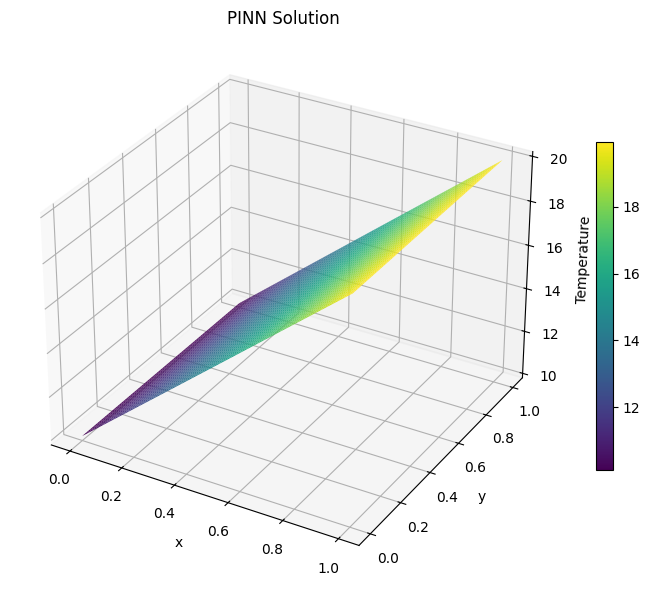

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# Parameters
# ==========================================================

torch.manual_seed(1234)
np.random.seed(1234)

device = torch.device("cpu")

# ==========================================================
# PINN Network
# ==========================================================

class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 1)
        )

    def forward(self, x, y):
        return self.net(torch.cat([x, y], dim=1))


model = PINN().to(device)

# ==========================================================
# Optimizer
# ==========================================================

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ==========================================================
# PINN Loss
# ==========================================================

def pinn_loss():

    # ------------------------------------------------------
    # Interior points
    # ------------------------------------------------------

    Nf = 1000

    x = torch.rand(
        Nf, 1,
        requires_grad=True
    ).to(device)

    y = torch.rand(
        Nf, 1,
        requires_grad=True
    ).to(device)

    u = model(x, y)

    # ------------------------------------------------------
    # u_x
    # ------------------------------------------------------

    u_x = torch.autograd.grad(
        u,
        x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # ------------------------------------------------------
    # u_xx
    # ------------------------------------------------------

    u_xx = torch.autograd.grad(
        u_x,
        x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    # ------------------------------------------------------
    # u_y
    # ------------------------------------------------------

    u_y = torch.autograd.grad(
        u,
        y,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # ------------------------------------------------------
    # u_yy
    # ------------------------------------------------------

    u_yy = torch.autograd.grad(
        u_y,
        y,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True
    )[0]

    # ------------------------------------------------------
    # 2D Laplace Equation
    #
    # u_xx + u_yy = 0
    # ------------------------------------------------------

    loss_pde = (
        u_xx + u_yy
    ).pow(2).mean()

    # ======================================================
    # Left Boundary
    #
    # u(0,y) = 10
    # ======================================================

    Nb = 500

    yb = torch.rand(Nb, 1).to(device)

    xl = torch.zeros_like(yb)

    ul = model(xl, yb)

    loss_left = (
        (ul - 10.0) ** 2
    ).mean()

    # ======================================================
    # Right Boundary
    #
    # u(1,y) = 20
    # ======================================================

    xr = torch.ones_like(yb)

    ur = model(xr, yb)

    loss_right = (
        (ur - 20.0) ** 2
    ).mean()

    # ======================================================
    # Bottom Boundary
    #
    # u(x,0) = 10 + 10x
    # ======================================================

    xb = torch.rand(Nb, 1).to(device)

    y_bottom = torch.zeros_like(xb)

    ub = model(xb, y_bottom)

    target_bottom = 10.0 + 10.0 * xb

    loss_bottom = (
        (ub - target_bottom) ** 2
    ).mean()

    # ======================================================
    # Top Boundary
    #
    # u(x,1) = 10 + 10x
    # ======================================================

    y_top = torch.ones_like(xb)

    utop = model(xb, y_top)

    target_top = 10.0 + 10.0 * xb

    loss_top = (
        (utop - target_top) ** 2
    ).mean()

    # ======================================================
    # Total PINN Loss
    # ======================================================

    loss = (
        loss_pde
        + 10 * loss_left
        + 10 * loss_right
        + 10 * loss_bottom
        + 10 * loss_top
    )

    return loss


# ==========================================================
# Adam Training
# ==========================================================

epochs = 5000

print("Training with Adam...")

for epoch in range(epochs):

    loss = pinn_loss()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 1000 == 0:

        print(
            f"Epoch {epoch:5d}  "
            f"Loss = {loss.item():.6e}"
        )


# ==========================================================
# Prediction
# ==========================================================

n_test = 100

x_test = torch.linspace(
    0, 1, n_test
).to(device)

y_test = torch.linspace(
    0, 1, n_test
).to(device)

X, Y = torch.meshgrid(
    x_test,
    y_test,
    indexing="ij"
)

x_flat = X.reshape(-1, 1)
y_flat = Y.reshape(-1, 1)

# ----------------------------------------------------------
# PINN Prediction
# ----------------------------------------------------------

with torch.no_grad():

    u_pinn = model(
        x_flat,
        y_flat
    )

u_pinn = u_pinn.reshape(
    n_test,
    n_test
).cpu().numpy()


# ==========================================================
# Plot: PINN Solution
# ==========================================================

fig = plt.figure(figsize=(8, 6))

ax1 = fig.add_subplot(
    1, 1, 1,
    projection="3d"
)

surf1 = ax1.plot_surface(
    X.cpu().numpy(),
    Y.cpu().numpy(),
    u_pinn,
    cmap="viridis"
)

ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("Temperature")

ax1.set_title(
    "PINN Solution"
)

fig.colorbar(
    surf1,
    ax=ax1,
    shrink=0.6
)

plt.tight_layout()

plt.show()

Training with Adam...
Epoch     0  Loss = 9.803363e+03
Epoch  1000  Loss = 5.083444e-01
Epoch  2000  Loss = 6.636606e-02
Epoch  3000  Loss = 2.460195e-02
Epoch  4000  Loss = 8.460198e-03

Starting L-BFGS optimization...
L-BFGS Finished!

Comparison:
Maximum absolute error = 4.187584e-03
Mean absolute error    = 6.605252e-04
RMSE                   = 1.020531e-03


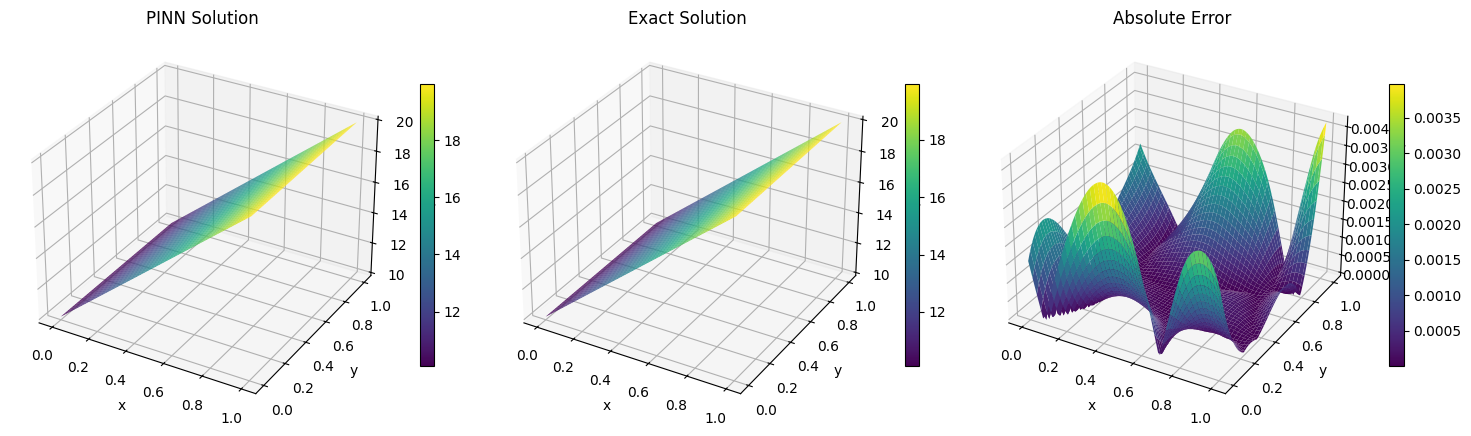

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# Parameters
# ==========================================================

torch.manual_seed(1234)
np.random.seed(1234)

device = torch.device("cpu")

# ==========================================================
# PINN Network
# ==========================================================

class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 1)
        )

    def forward(self, x, y):
        return self.net(torch.cat([x, y], dim=1))


model = PINN().to(device)

# ==========================================================
# Optimizers
# ==========================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5000,
    gamma=0.5
)

# ==========================================================
# PINN Loss
# ==========================================================

def pinn_loss():

    # ------------------------------------------------------
    # Interior points
    # ------------------------------------------------------

    Nf = 1000

    x = torch.rand(
        Nf, 1,
        requires_grad=True
    ).to(device)

    y = torch.rand(
        Nf, 1,
        requires_grad=True
    ).to(device)

    u = model(x, y)

    # ------------------------------------------------------
    # u_x
    # ------------------------------------------------------

    u_x = torch.autograd.grad(
        u,
        x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # ------------------------------------------------------
    # u_xx
    # ------------------------------------------------------

    u_xx = torch.autograd.grad(
        u_x,
        x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    # ------------------------------------------------------
    # u_y
    # ------------------------------------------------------

    u_y = torch.autograd.grad(
        u,
        y,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # ------------------------------------------------------
    # u_yy
    # ------------------------------------------------------

    u_yy = torch.autograd.grad(
        u_y,
        y,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True
    )[0]

    # ------------------------------------------------------
    # 2D Laplace Equation
    #
    # u_xx + u_yy = 0
    # ------------------------------------------------------

    loss_pde = (
        u_xx + u_yy
    ).pow(2).mean()

    # ======================================================
    # Left Boundary
    #
    # u(0,y) = 10
    # ======================================================

    Nb = 500

    yb = torch.rand(Nb, 1).to(device)

    xl = torch.zeros_like(yb)

    ul = model(xl, yb)

    loss_left = (
        (ul - 10.0) ** 2
    ).mean()

    # ======================================================
    # Right Boundary
    #
    # u(1,y) = 20
    # ======================================================

    xr = torch.ones_like(yb)

    ur = model(xr, yb)

    loss_right = (
        (ur - 20.0) ** 2
    ).mean()

    # ======================================================
    # Bottom Boundary
    #
    # u(x,0) = 10 + 10x
    # ======================================================

    xb = torch.rand(Nb, 1).to(device)

    y_bottom = torch.zeros_like(xb)

    ub = model(xb, y_bottom)

    target_bottom = 10.0 + 10.0 * xb

    loss_bottom = (
        (ub - target_bottom) ** 2
    ).mean()

    # ======================================================
    # Top Boundary
    #
    # u(x,1) = 10 + 10x
    # ======================================================

    y_top = torch.ones_like(xb)

    utop = model(xb, y_top)

    target_top = 10.0 + 10.0 * xb

    loss_top = (
        (utop - target_top) ** 2
    ).mean()

    # ======================================================
    # Total PINN Loss
    # ======================================================

    loss = (
        loss_pde
        + 10 * loss_left
        + 10 * loss_right
        + 10 * loss_bottom
        + 10 * loss_top
    )

    return loss


# ==========================================================
# Adam Training
# ==========================================================

epochs = 5000

print("Training with Adam...")

for epoch in range(epochs):

    loss = pinn_loss()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    scheduler.step()

    if epoch % 1000 == 0:

        print(
            f"Epoch {epoch:5d}  "
            f"Loss = {loss.item():.6e}"
        )


# ==========================================================
# L-BFGS Fine Tuning
# ==========================================================

print("\nStarting L-BFGS optimization...")

optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=500,
    tolerance_grad=1e-9,
    tolerance_change=1e-9,
    history_size=100,
    line_search_fn="strong_wolfe"
)


def closure():

    optimizer_lbfgs.zero_grad()

    loss = pinn_loss()

    loss.backward()

    return loss


optimizer_lbfgs.step(closure)

print("L-BFGS Finished!")


# ==========================================================
# Prediction
# ==========================================================

n_test = 100

x_test = torch.linspace(
    0, 1, n_test
).to(device)

y_test = torch.linspace(
    0, 1, n_test
).to(device)

X, Y = torch.meshgrid(
    x_test,
    y_test,
    indexing="ij"
)

x_flat = X.reshape(-1, 1)
y_flat = Y.reshape(-1, 1)

# ----------------------------------------------------------
# PINN Prediction
# ----------------------------------------------------------

with torch.no_grad():

    u_pinn = model(
        x_flat,
        y_flat
    )

u_pinn = u_pinn.reshape(
    n_test,
    n_test
).cpu().numpy()


# ==========================================================
# Exact Solution
# ==========================================================

def exact_solution(x, y):

    return 10.0 + 10.0 * x


u_exact = exact_solution(
    X.cpu().numpy(),
    Y.cpu().numpy()
)


# ==========================================================
# Absolute Error
# ==========================================================

error = np.abs(
    u_pinn - u_exact
)

print("\nComparison:")

print(
    f"Maximum absolute error = "
    f"{np.max(error):.6e}"
)

print(
    f"Mean absolute error    = "
    f"{np.mean(error):.6e}"
)

print(
    f"RMSE                   = "
    f"{np.sqrt(np.mean(error**2)):.6e}"
)


# ==========================================================
# Plot: PINN vs Exact
# ==========================================================

fig = plt.figure(figsize=(15, 5))

# ----------------------------------------------------------
# PINN Solution
# ----------------------------------------------------------

ax1 = fig.add_subplot(
    1, 3, 1,
    projection="3d"
)

surf1 = ax1.plot_surface(
    X.cpu().numpy(),
    Y.cpu().numpy(),
    u_pinn,
    cmap="viridis"
)

ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("Temperature")

ax1.set_title(
    "PINN Solution"
)

fig.colorbar(
    surf1,
    ax=ax1,
    shrink=0.6
)


# ----------------------------------------------------------
# Exact Solution
# ----------------------------------------------------------

ax2 = fig.add_subplot(
    1, 3, 2,
    projection="3d"
)

surf2 = ax2.plot_surface(
    X.cpu().numpy(),
    Y.cpu().numpy(),
    u_exact,
    cmap="viridis"
)

ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("Temperature")

ax2.set_title(
    "Exact Solution"
)

fig.colorbar(
    surf2,
    ax=ax2,
    shrink=0.6
)


# ----------------------------------------------------------
# Absolute Error
# ----------------------------------------------------------

ax3 = fig.add_subplot(
    1, 3, 3,
    projection="3d"
)

surf3 = ax3.plot_surface(
    X.cpu().numpy(),
    Y.cpu().numpy(),
    error,
    cmap="viridis"
)

ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("Absolute Error")

ax3.set_title(
    "Absolute Error"
)

fig.colorbar(
    surf3,
    ax=ax3,
    shrink=0.6
)

plt.tight_layout()

plt.show()